假设数据为一个梯形

$$
y = \begin{cases}
2x, & x \leq 2 \\
4, & 2 < x \leq 4 \\
-2x-12, & x > 4
\end{cases}
$$

In [40]:
# 把数据表示出来
import pandas as pd
import numpy as np
from torch import nn
import torch

# 方法1
def piecewise_function(x):
    if x <= 2:
        return x * 2
    elif 2 < x <= 4:
        return 4
    else:
        return -2 * x -12

x_values = [0, 1, 2, 3, 4, 5, 6]
y_values = [piecewise_function(x) for x in x_values]

print(list(zip(x_values, y_values)))

[(0, 0), (1, 2), (2, 4), (3, 4), (4, 4), (5, -22), (6, -24)]


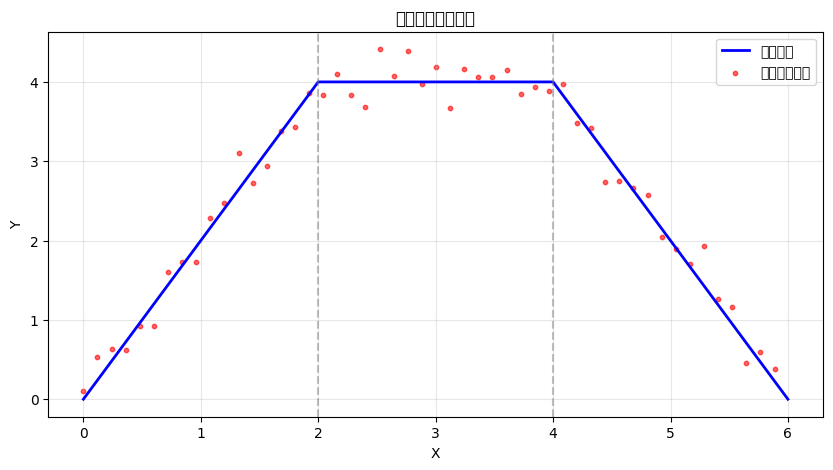

In [33]:
# 方法2
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# 1. 设置随机种子，确保结果可复现
np.random.seed(42)

# 2. 生成X数据：在0到6之间生成1000个点
n_samples = 1000
X = np.linspace(0, 6, n_samples)  # 均匀分布，适合拟合
# 或者用随机采样： X = np.random.uniform(0, 6, n_samples)

# 3. 向量化计算Y（重点）
# np.where 就是向量化的 if-else，可以一次性处理整个数组
Y = np.where(X <= 2,
             2 * X,                      # 条件1成立
             np.where(X <= 4,
                      4,                 # 条件2成立
                      -2 * X + 12))      # 否则

# 4. 添加高斯噪声，模拟真实观测数据
noise_std = 0.2  # 噪声标准差
Y_noisy = Y + np.random.normal(0, noise_std, size=n_samples)

# 5. 可视化检查
plt.figure(figsize=(10, 5))
plt.plot(X, Y, 'b-', linewidth=2, label='真实函数')
plt.scatter(X[::20], Y_noisy[::20], s=10, c='red', alpha=0.6, label='带噪声采样点')  # 每隔20个点画一个，避免太密集
plt.axvline(x=2, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=4, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('分段函数数据生成')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

先试一下线性回归

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [23]:
lr = LinearRegression()

In [34]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [25]:
print(X_train.shape)
print(y_train.shape)

(800,)
(800,)


In [35]:
X_train = X_train.reshape(-1,1)
X_test = X_test.reshape(-1, 1)
y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1, 1)
print(X_train.shape)

(800, 1)


In [29]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


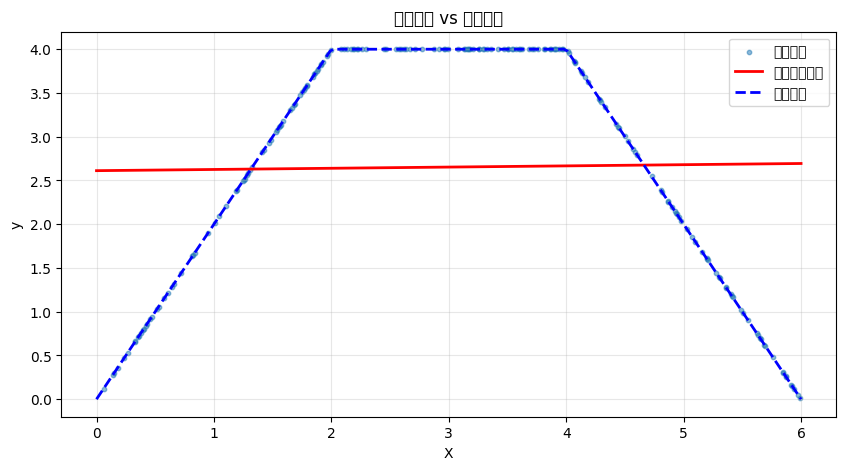

In [30]:
# 结果
X_plot = np.linspace(0, 6, 200).reshape(-1, 1)
y_pred = lr.predict(X_plot)

plt.figure(figsize=(10, 5))
plt.scatter(X_test, y_test, s=10, alpha=0.5, label='测试样本')
plt.plot(X_plot, y_pred, 'r-', linewidth=2, label='线性回归预测')
plt.plot(X_plot, np.where(X_plot <= 2, 2*X_plot,
                          np.where(X_plot <= 4, 4, -2*X_plot + 12)),
         'b--', linewidth=2, label='真实函数')
plt.xlabel('X')
plt.ylabel('y')
plt.title('线性回归 vs 分段函数')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
print("训练集R²:", lr.score(X_train, y_train))
print("测试集R²:", lr.score(X_test, y_test))

训练集R²: 0.00031601725217700327
测试集R²: -0.004543453585877488


下面用MLP试一下

In [39]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 1)
(200, 1)
(800, 1)
(200, 1)


In [41]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# 先把 NumPy 数组转成 PyTorch 张量（必须！）
X_train_t = torch.from_numpy(X_train).reshape(-1, 1).float()
y_train_t = torch.from_numpy(y_train).reshape(-1, 1).float()
X_test_t  = torch.from_numpy(X_test).reshape(-1, 1).float()
y_test_t  = torch.from_numpy(y_test).reshape(-1, 1).float()

# 现在再创建 Dataset 和 DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [43]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 打包成 DataLoader，方便批量训练
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)


In [ ]:
# class MyMLP(nn.Module):
#     def __init__(self,hidden_layer_sizes,neurons_per_layer,X,y):
#         super(MyMLP, self).__init__()
#         self.hidden_layer_sizes = hidden_layer_sizes
#         self.neurons_per_layer = neurons_per_layer
#         self.W = []
#         self.b = []
#         self.X = X
#         self.y = y
#
#     def sigmod(self,x):
#         return 1 / (1 + np.exp(-x))
#
#     def forward(self,X,W,b):
#         self.X = X
#         self.W = W
#         self.b = b
#         for layer in range(self.neurons_per_layer):
#             y = X @ W[layer] + b[layer]
#         return y

"""
我要自己手写一个MLP，主要是自己手写前向传播的所有过程，反向传播调用相应的包就行，我用的是pytorch，我们一点点开始。 首先，我定义一个类MyMLP，参数要有哪些，隐藏层的个数（int）、每个隐藏层神经元的个数（list[int]）、输出y_hat的维度（int）、输入X、输入y、参数W（应该是根据隐藏层的个数、每层神经元的个数、X来共同决定，然后直接进行初始化（用正态分布），但是我不知道这个该怎么写）、参数b（list[int] 每层的b根据每层神经元的个数来初始化） 这样可以吗，讲解一下
"""

首先，假设输入X n行d列，n为样本数量，d为特征数量
例如MNIST X=(60000,784)

输入层
784
↓
隐藏层1
256
↓
隐藏层2
128
↓
输出层
10

In [ ]:
# class MyMLP(nn.Module):
#
#     def __init__(
#         self,
#         input_dim,      # 输入X的shape
#         hidden_dims,    # 每层隐藏层神经元的个数
#         output_dim      # 输出y的维度
#     ):
#         super(MyMLP, self).__init__()

W 怎么初始化？
我的理解：W 根据隐藏层个数、每层神经元个数、X共同决定

但是W 只由网络结构决定，和具体 X 无关

例如 输入X=(64,784)
batch=64
第一层：
784 -> 256
那么：
W1:(784, 256)

第二层：
256 -> 128
那么：
W2:(256，128)

In [ ]:
# # so 如何自动生成W
# layers = [784,256,128,10]
# for i in range(len(layers)-1):
#     in_dim = layers[i]
#     out_dim = layers[i+1]
# W = torch.randn(
#     in_dim,
#     out_dim
# )

参数应该保存在哪里？

PyTorch 有一个要求：
如果参数需要训练,必须是：nn.Parameter
例如 self.W1 = nn.Parameter(...) optimizer才知道更新它

In [92]:
class MyMLP(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dims,
        output_dim
    ):

        super().__init__()

        layers = [input_dim] + hidden_dims + [output_dim]

        self.W = nn.ParameterList()
        self.b = nn.ParameterList()


        for i in range(len(layers)-1):
            W = nn.Parameter(
                torch.empty(
                    layers[i],
                    layers[i+1]
                )
            )
            nn.init.kaiming_normal_(W)

            b = nn.Parameter(
                torch.zeros(layers[i+1])
            )

            self.W.append(W)
            self.b.append(b)

    def relu(self,X):
        # if X > 0:
        #     return X
        # else:
        #     return 0      错误写法
        return torch.clamp(X,min=0)

    # def forward(self,X):
    #     Z = X @ self.W + self.b
    #     A = self.relu(Z)
    #     return A          单次

    def forward(self,X):

        for i in range(len(self.W)):

            X = X @ self.W[i] + self.b[i]

            if i != len(self.W)-1:
                X = self.relu(X)

        return X



In [47]:
"""
实际上实现了
nn.Sequential(
    nn.Linear(784,256),
    nn.ReLU(),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.Linear(128,10)
)
1.Linear 的参数保存
2.权重初始化
3.forward传播
4.激活函数
全都自己写了
"""

'\n实际上实现了\nnn.Sequential(\n    nn.Linear(784,256),\n    nn.ReLU(),\n    nn.Linear(256,128),\n    nn.ReLU(),\n    nn.Linear(128,10)\n)\n1.Linear 的参数保存\n2.权重初始化\n3.forward传播\n4.激活函数\n全都自己写了\n'

In [101]:
model = MyMLP(
    input_dim=1,
    hidden_dims=[5,4,4,3],
    output_dim=1
)

In [102]:
from torch.optim import optimizer
from torch.nn import CrossEntropyLoss, MSELoss

loss_fn = MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [103]:
epochs = 100
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        # 前向传播
        y_hat = model(X_batch)

        # 计算loss
        loss = loss_fn(y_batch, y_hat)

        # 清空梯度
        optimizer.zero_grad()

        # 反向传播
        loss.backward()

        # 更新参数
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(
            f"epoch:{epoch+1}, loss:{total_loss/len(train_loader):.6f}"
        )

epoch:10, loss:1.850037
epoch:20, loss:0.636080
epoch:30, loss:0.171897
epoch:40, loss:0.061227
epoch:50, loss:0.023008
epoch:60, loss:0.008529
epoch:70, loss:0.003813
epoch:80, loss:0.002075
epoch:90, loss:0.001517
epoch:100, loss:0.001113


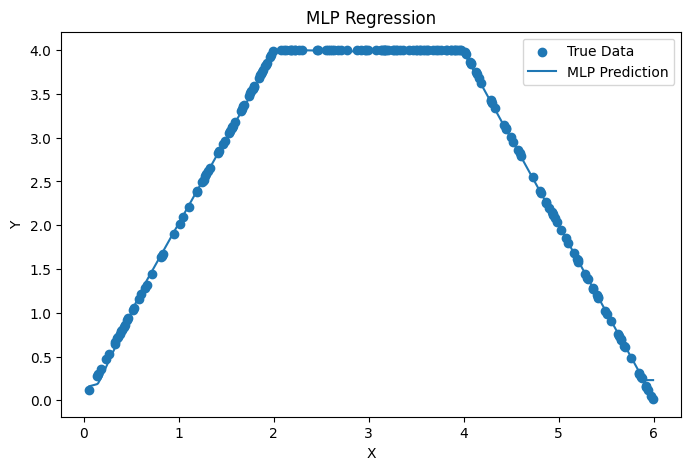

In [104]:
# 结果可视化
import torch
import matplotlib.pyplot as plt


# ============================
# 1. 模型进入测试模式
# ============================

model.eval()


# ============================
# 2. 保证 X_test 是 Tensor
# ============================

if not isinstance(X_test, torch.Tensor):
    X_test_tensor = torch.tensor(X_test).float()
else:
    X_test_tensor = X_test.float()


if not isinstance(y_test, torch.Tensor):
    y_test_tensor = torch.tensor(y_test).float()
else:
    y_test_tensor = y_test.float()



# ============================
# 3. 模型预测
# ============================

with torch.no_grad():

    y_pred = model(X_test_tensor)



# ============================
# 4. Tensor 转 numpy
# ============================

X_np = X_test_tensor.numpy()

y_true = y_test_tensor.numpy()

y_pred_np = y_pred.numpy()



# ============================
# 5. 排序
# 防止散点连接乱
# ============================

idx = X_np[:,0].argsort()


X_sorted = X_np[idx]

y_true_sorted = y_true[idx]

y_pred_sorted = y_pred_np[idx]



# ============================
# 6. 绘图
# ============================

plt.figure(figsize=(8,5))


# 真实数据
plt.scatter(
    X_sorted,
    y_true_sorted,
    label="True Data"
)


# MLP预测结果
plt.plot(
    X_sorted,
    y_pred_sorted,
    label="MLP Prediction"
)



plt.xlabel("X")

plt.ylabel("Y")

plt.title("MLP Regression")


plt.legend()

plt.show()